# Risk Attribution: Menchero Methodology ###

In [1]:
# Import Libraries

# Data Management
import pandas as pd
import numpy as np

# Plots
import matplotlib.pyplot as plt

# Handle Files
import sys
import os

# Import Local Functions
sys.path.append(os.path.abspath("../source"))
from config import get_tickers
from factors_toolkit import FamaFrenchFactors
from markowitz_portfolios_toolkit import markowitz_weights
from markowitz_portfolios_toolkit import portfolio_variance

### Building a Portfolio ###

In [2]:
tickers = get_tickers("6.3")

tickers

['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA', 'TSLA']

In [3]:
# Import the Returns Data
returns_df = pd.read_csv(r'../additional_data/stocks_returns.csv')
returns_df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
returns_df.set_index('Date', inplace=True)
returns_df.index = pd.to_datetime(returns_df.index)

returns_df

,A,AAL,AAP,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,...,XEL,XOM,XRAY,XRX,XYL,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,NaN,NaN,NaN,0.048789,NaN,NaN,0.001281,-0.039193,NaN,-0.021506,...,0.002275,-0.008643,0.009709,0.018928,NaN,0.019293,NaN,0.016878,-0.003114,NaN
1999-01-06,NaN,NaN,NaN,-0.036742,NaN,NaN,-0.007712,0.000000,NaN,-0.036462,...,0.004535,0.039154,0.009615,0.019087,NaN,0.015170,NaN,0.002090,0.001039,NaN
1999-01-07,NaN,NaN,NaN,0.074963,NaN,NaN,-0.012987,-0.005831,NaN,0.020998,...,-0.004535,-0.001670,-0.002395,-0.004610,NaN,-0.005031,NaN,0.022705,-0.007295,NaN
1999-01-08,NaN,NaN,NaN,0.000000,NaN,NaN,-0.003929,-0.005865,NaN,0.014185,...,-0.006841,-0.005870,-0.012063,-0.004631,NaN,0.002519,NaN,0.104544,0.002090,NaN
1999-01-11,NaN,NaN,NaN,0.019256,NaN,NaN,-0.013211,-0.048202,NaN,0.003834,...,-0.023150,-0.042085,-0.032062,0.014337,NaN,0.026073,NaN,-0.045120,-0.027515,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011082,0.005780,-0.000457,0.011413,0.008985,0.003488,0.003929,0.006278,0.007940,0.002683,...,0.007210,0.000940,-0.002642,-0.023556,0.005432,0.008480,0.004484,0.012187,0.010791,0.002553
2024-12-26,-0.001986,0.000000,0.011595,0.003171,-0.004454,0.002442,0.004434,0.002802,-0.003324,0.004944,...,-0.000440,0.000845,0.013663,-0.006522,0.002705,0.007380,-0.000466,0.003559,0.006889,0.004966
2024-12-27,-0.002137,0.000000,-0.004077,-0.013331,-0.006663,-0.014403,-0.002432,-0.006369,-0.011862,-0.008208,...,-0.000587,-0.000094,-0.003163,-0.002183,-0.007966,-0.005678,-0.003549,-0.019799,-0.012179,-0.005574


In [50]:
# Make the portfolio DataFrame
portfolio_holdings_df = returns_df[tickers]
portfolio_holdings_df = portfolio_holdings_df.loc['2015':]

portfolio_holdings_df

,AAPL,AMZN,GOOG,META,MSFT,NVDA,TSLA
Date,,,,,,,
2015-01-02,-0.009558,-0.005914,-0.003025,0.005496,0.006652,0.003982,-0.014036
2015-01-05,-0.028576,-0.020731,-0.021066,-0.016192,-0.009238,-0.017035,-0.042950
2015-01-06,0.000094,-0.023098,-0.023450,-0.013565,-0.014786,-0.030787,0.005648
2015-01-07,0.013925,0.010544,-0.001715,0.000000,0.012625,-0.002609,-0.001563
2015-01-08,0.037702,0.006813,0.003148,0.026309,0.028993,0.036927,-0.001566
...,...,...,...,...,...,...,...
2024-12-24,0.011413,0.017573,0.008029,0.013084,0.009330,0.003930,0.070991
2024-12-26,0.003171,-0.008770,-0.002382,-0.007266,-0.002781,-0.002070,-0.017787
2024-12-27,-0.013331,-0.014641,-0.015647,-0.005885,-0.017453,-0.021088,-0.050745


In [51]:
# Portfolio's Returns and Variances
expected_returns = portfolio_holdings_df.mean()
covariance_matrix = portfolio_holdings_df.cov()

In [52]:
# Obtain Weights
p_weights = markowitz_weights(
    expected_returns, 
    covariance_matrix,
    0.0015
)

p_weights

array([ 0.2486968 ,  0.22631574,  0.01926273, -0.14106151,  0.23360817,
        0.39868515,  0.01449291])

In [53]:
# Create a Portfolio Weights DF
portfolio_weights = pd.Series(
    p_weights,
    index = portfolio_holdings_df.columns,
    name = 'weights'
)

portfolio_weights

AAPL    0.248697
AMZN    0.226316
GOOG    0.019263
META   -0.141062
MSFT    0.233608
NVDA    0.398685
TSLA    0.014493
Name: weights, dtype: float64

In [54]:
# Portfolios Variance
p_variance = portfolio_variance(p_weights, portfolio_holdings_df)

p_variance

0.00039377254002648997

In [55]:
# Portfolio Returns
portfolio_returns = portfolio_holdings_df @ p_weights
portfolio_returns.name = 'portfolio_returns'

In [56]:
# Holdings Standard Deviations
holdings_stds = portfolio_holdings_df.std()

holdings_stds

AAPL    0.017929
AMZN    0.020570
GOOG    0.017915
META    0.023842
MSFT    0.017088
NVDA    0.030370
TSLA    0.035904
dtype: float64

In [57]:
# Holding's correlations with the portfolio
corr_with_portfolio = portfolio_holdings_df.corrwith(portfolio_returns)

corr_with_portfolio

AAPL    0.759459
AMZN    0.730249
GOOG    0.679695
META    0.516841
MSFT    0.806042
NVDA    0.915539
TSLA    0.496642
dtype: float64

The reader can review the derivation of the x-sigma-rho methodology in Section 3 of this module’s PDF.

In [58]:
# Now get the x-sigma-rho
RC = portfolio_weights * holdings_stds * corr_with_portfolio
RC.name = 'risk_contribution'

RC

AAPL    0.003386
AMZN    0.003400
GOOG    0.000235
META   -0.001738
MSFT    0.003218
NVDA    0.011085
TSLA    0.000258
Name: risk_contribution, dtype: float64

In [59]:
RC.sum()

0.019843702780138854

In [60]:
np.sqrt(p_variance)

0.01984370278013884

In [61]:
# In percentage
RC_percent = (RC / np.sqrt(p_variance)) * 100

RC_percent

AAPL    17.065203
AMZN    17.131479
GOOG     1.182048
META    -8.759752
MSFT    16.214634
NVDA    55.864058
TSLA     1.302329
Name: risk_contribution, dtype: float64

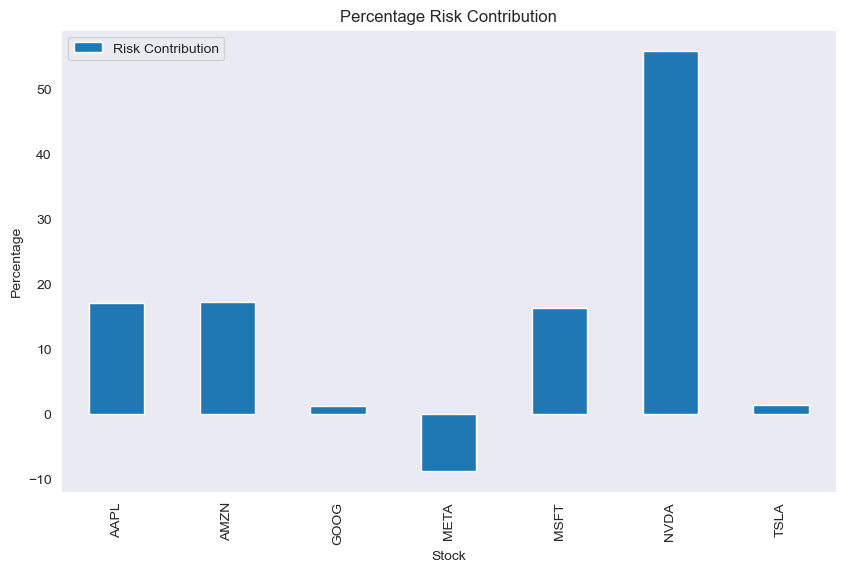

In [62]:
# Create Plot
plt.figure(figsize=(10, 6))
RC_percent.plot(kind='bar', label='Risk Contribution')

# Config
plt.title('Percentage Risk Contribution')
plt.xlabel('Stock')
plt.ylabel('Percentage')
plt.legend()
plt.grid()

# Show
plt.show() 

In [63]:
# Marginal Risk Contribution
MRC = holdings_stds * corr_with_portfolio
MRC.name = 'marginal_risk_contribution'

MRC

AAPL    0.013616
AMZN    0.015021
GOOG    0.012177
META    0.012323
MSFT    0.013773
NVDA    0.027805
TSLA    0.017831
Name: marginal_risk_contribution, dtype: float64

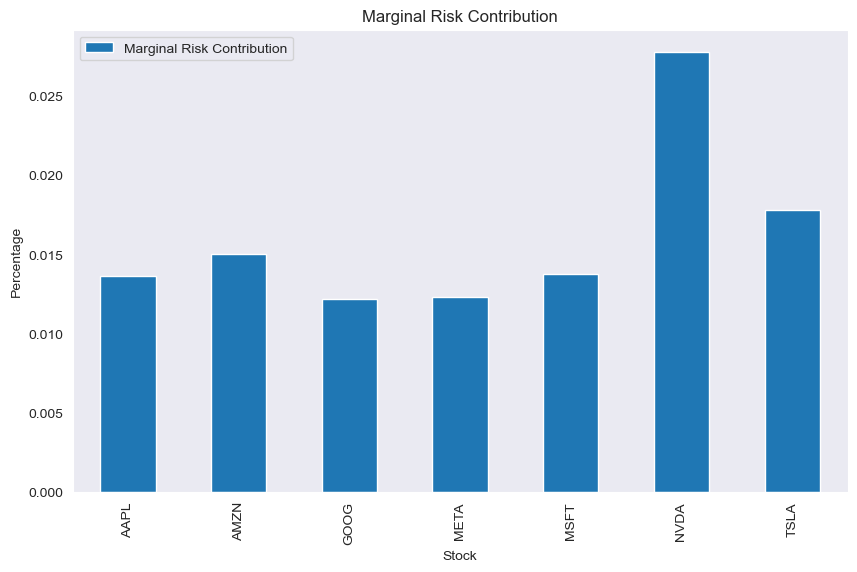

In [64]:
# Create Plot
plt.figure(figsize=(10, 6))
MRC.plot(kind='bar', label='Marginal Risk Contribution')

# Config
plt.title('Marginal Risk Contribution')
plt.xlabel('Stock')
plt.ylabel('Percentage')
plt.legend()
plt.grid()

# Show
plt.show() 

We conclude that our portfolio’s risk is more sensitive to NVDA’s exposure than to that of any other stock in the portfolio.

### Now Using Factor ###

In [65]:
# We can download the premiums in the Fama and French website
premiums_df = pd.read_csv(r'../additional_data/ff_size_n_value.csv')
premiums_df.set_index('date', inplace=True)
premiums_df.index = pd.to_datetime(premiums_df.index)
premiums_df.columns = ['mkt_premium', 'smb_premium', 'hml_premium']

premiums_df

,mkt_premium,smb_premium,hml_premium
date,,,
1999-01-04,-0.0018,0.0014,0.0045
1999-01-05,0.0110,-0.0074,-0.0007
1999-01-06,0.0211,-0.0058,-0.0059
1999-01-07,-0.0007,0.0050,-0.0030
1999-01-08,0.0045,0.0009,0.0027
...,...,...,...
2024-12-24,0.0111,-0.0009,-0.0006
2024-12-26,0.0001,0.0104,-0.0019
2024-12-27,-0.0117,-0.0065,0.0057


In [66]:
# Get the important data for the Risk-Free Rate
rfr = pd.read_csv(r"../additional_data/risk_free_rate.csv")
rfr.set_index('Date', inplace=True)
rfr.index = pd.to_datetime(rfr.index)

rfr

,risk_free_rate
Date,
1999-01-05,0.000131
1999-01-06,0.000131
1999-01-07,0.000132
1999-01-08,0.000135
1999-01-11,0.000135
...,...
2024-12-24,0.000128
2024-12-26,0.000127
2024-12-27,0.000128


In [67]:
# Now calculate the betas
portfolio_premium = portfolio_returns - rfr['risk_free_rate']

# Check if the Function Works
parameters = FamaFrenchFactors(
    portfolio_premium,
    premiums_df['mkt_premium'],
    premiums_df['smb_premium'],
    premiums_df['hml_premium'],
)

parameters

{'alpha': 0.0006733338458726573,
 'mkt_beta': 1.372366301619933,
 'smb_beta': -0.20181513434070109,
 'hml_beta': -0.6736836682687165}

In [68]:
# Create the Parameters Series
portfolio_parameters = pd.DataFrame([parameters])
portfolio_parameters.columns = ['const', 'mkt_premium', 'smb_premium', 'hml_premium']
portfolio_parameters = portfolio_parameters.T
portfolio_parameters.columns = ['parameters']
portfolio_parameters = portfolio_parameters['parameters']
portfolio_parameters = portfolio_parameters.iloc[1:]

portfolio_parameters

mkt_premium    1.372366
smb_premium   -0.201815
hml_premium   -0.673684
Name: parameters, dtype: float64

In [69]:
# Get the standard deviations of the premiums
premiums_std = premiums_df[['mkt_premium', 'smb_premium', 'hml_premium']].std()
premiums_std.name = 'premium_std'

premiums_std

mkt_premium    0.012348
smb_premium    0.006433
hml_premium    0.007793
Name: premium_std, dtype: float64

In [70]:
# Holding's correlations with the portfolio
factors_corr_with_portfolio = premiums_df[['mkt_premium', 'smb_premium', 'hml_premium']].corrwith(portfolio_returns)

factors_corr_with_portfolio

mkt_premium    0.797423
smb_premium    0.104746
hml_premium   -0.356102
dtype: float64

In [71]:
# Now get the x-sigma-rho
RC = portfolio_parameters * premiums_std * factors_corr_with_portfolio
RC.name = 'risk_contribution'

RC

mkt_premium    0.013513
smb_premium   -0.000136
hml_premium    0.001870
Name: risk_contribution, dtype: float64

In [72]:
RC.sum()

0.015246201700371127

In [73]:
np.sqrt(portfolio_returns.var()) - RC.sum()

0.004597501079767703

In [74]:
# In percentage
RC_percent = (RC / np.sqrt(p_variance)) * 100

RC_percent

mkt_premium    68.095128
smb_premium    -0.685332
hml_premium     9.421640
Name: risk_contribution, dtype: float64

In [75]:
# Idiosyncratic Risk
idio_risk = 100 - RC_percent.sum()
idio_risk

23.16856450989205

### Correlation Drilldown ###

In Section 3 of the PDF, the correlation drilldown is explored in greater depth and with more mathematical rigor

In [76]:
# Calculate the Sigmas
sigmas = portfolio_holdings_df.std()

sigmas

AAPL    0.017929
AMZN    0.020570
GOOG    0.017915
META    0.023842
MSFT    0.017088
NVDA    0.030370
TSLA    0.035904
dtype: float64

In [77]:
# The Covariances
gammas = portfolio_holdings_df.cov()

gammas

,AAPL,AMZN,GOOG,META,MSFT,NVDA,TSLA
AAPL,0.000321,0.000205,0.000194,0.000224,0.000210,0.000298,0.000273
AMZN,0.000205,0.000423,0.000240,0.000289,0.000232,0.000324,0.000290
GOOG,0.000194,0.000240,0.000321,0.000266,0.000219,0.000290,0.000237
META,0.000224,0.000289,0.000266,0.000568,0.000237,0.000349,0.000276
MSFT,0.000210,0.000232,0.000219,0.000237,0.000292,0.000316,0.000250
NVDA,0.000298,0.000324,0.000290,0.000349,0.000316,0.000922,0.000446
TSLA,0.000273,0.000290,0.000237,0.000276,0.000250,0.000446,0.001289


In [78]:
# Portfolio Sigma
sigma_P = np.sqrt(p_variance)

sigma_P

0.01984370278013884

In [79]:
# The Correlations
rhos = portfolio_holdings_df.corr()

rhos

,AAPL,AMZN,GOOG,META,MSFT,NVDA,TSLA
AAPL,1.000000,0.556799,0.605191,0.524053,0.684992,0.546557,0.424679
AMZN,0.556799,1.000000,0.650866,0.590110,0.659490,0.518332,0.392589
GOOG,0.605191,0.650866,1.000000,0.623760,0.716013,0.533673,0.368868
META,0.524053,0.590110,0.623760,1.000000,0.581870,0.481469,0.322380
MSFT,0.684992,0.659490,0.716013,0.581870,1.000000,0.609245,0.406697
NVDA,0.546557,0.518332,0.533673,0.481469,0.609245,1.000000,0.408577
TSLA,0.424679,0.392589,0.368868,0.322380,0.406697,0.408577,1.000000


In [80]:
# Let us check the drill-downs
decomp = pd.DataFrame(index=portfolio_holdings_df.columns, columns=portfolio_holdings_df.columns)

# Loop
for m in portfolio_holdings_df.columns:  # Stock m (rows)
    for n in portfolio_holdings_df.columns:  # Stock n (columns)
        
        term = portfolio_weights.loc[n] * (sigmas.loc[n] / sigma_P) * rhos.loc[m, n]
        
        decomp.loc[m, n] = term

decomp

,AAPL,AMZN,GOOG,META,MSFT,NVDA,TSLA
AAPL,0.224702,0.130624,0.010525,-0.08882,0.137795,0.333497,0.011136
AMZN,0.125114,0.234598,0.011319,-0.100016,0.132665,0.316274,0.010295
GOOG,0.135988,0.152692,0.017391,-0.105719,0.144036,0.325635,0.009673
META,0.117756,0.138439,0.010848,-0.169486,0.117051,0.293781,0.008454
MSFT,0.153919,0.154715,0.012452,-0.098619,0.201164,0.371747,0.010665
NVDA,0.122813,0.1216,0.009281,-0.081602,0.122558,0.610177,0.010714
TSLA,0.095426,0.0921,0.006415,-0.054639,0.081813,0.249304,0.026223


In [81]:
# If we sum horizontally
rho_m_R = decomp.sum(axis=1)
rho_m_R.name = 'rho_m_R'

rho_m_R

AAPL    0.759459
AMZN    0.730249
GOOG    0.679695
META    0.516841
MSFT    0.806042
NVDA    0.915539
TSLA    0.496642
Name: rho_m_R, dtype: object

In [82]:
# Check that both ways to calculate the correlation with the portfolio are valid
corr_with_portfolio

AAPL    0.759459
AMZN    0.730249
GOOG    0.679695
META    0.516841
MSFT    0.806042
NVDA    0.915539
TSLA    0.496642
dtype: float64

In [83]:
# Now let us discount the self-interaction factor from the correlations:
rho_m_R_discounted = rho_m_R - decomp.values.diagonal()
rho_m_R_discounted.name = 'rho_m_R_discounted'

rho_m_R_discounted

AAPL    0.534757
AMZN    0.495652
GOOG    0.662304
META    0.686328
MSFT    0.604879
NVDA    0.305363
TSLA    0.470419
Name: rho_m_R_discounted, dtype: object